# Solving CartPole-v1 with PPO (from scratch)

This notebook demonstrates how to solve the CartPole-v1 environment using a custom implementation of the Proximal Policy Optimization (PPO) algorithm in PyTorch. No external RL libraries are used.

---

**Note:** All environment and hyperparameter settings are now collected in a single `CONFIG` dictionary at the top of the notebook. To change the environment or any hyperparameter, simply edit the values in the config cell.

## 1. Install and Import Required Libraries
We will use gymnasium and torch for this implementation.

In [1]:
%pip install gymnasium tsilva-notebook-utils

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2. Set Up CartPole-v1 Environment
We will initialize the CartPole-v1 environment and display its basic information.

In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import platform, os

# --- Config dictionary for all hyperparameters and environment settings ---
def setup_config(env_id: str = "CartPole-v1"):
    common = dict(
        env_id=env_id,
        seed=42,
        gamma=0.98,
        lam=0.92,
        clip_epsilon=0.15,
        minibatch_size=128,
        episodes_per_epoch=20,
        eval_interval=5,
        eval_episodes=20,
        reward_threshold=200,
        policy_lr=1e-4,
        value_lr=5e-4,
        hidden_dim=128,
    )
    env_specific = {
        "CartPole-v1": dict(),
        # Add overrides for other envs here if needed
    }
    if env_id not in env_specific:
        raise ValueError(f"Unsupported env_id: {env_id}")
    return {**common, **env_specific[env_id]}

CONFIG = setup_config()

# --- Runtime metadata (optional, for reproducibility/info) ---
def runtime_metadata():
    return {
        "python_version": platform.python_version(),
        "run_host": os.uname().nodename,
    }
CONFIG.update(runtime_metadata())

# Set up the environment
env = gym.make(CONFIG['env_id'])
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


## 3. Implement PPO Agent
We will define the policy and value networks, and the PPO update step.

In [3]:
# Policy and Value Networks
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_dim=None):
        super().__init__()
        h = hidden_dim or CONFIG['hidden_dim']
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h), nn.Tanh(),
            nn.Linear(h, h), nn.Tanh(),
            nn.Linear(h, act_dim)
        )
    def forward(self, x):
        return self.net(x)

class ValueNet(nn.Module):
    def __init__(self, obs_dim, hidden_dim=None):
        super().__init__()
        h = hidden_dim or CONFIG['hidden_dim']
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h), nn.Tanh(),
            nn.Linear(h, h), nn.Tanh(),
            nn.Linear(h, 1)
        )
    def forward(self, x):
        return self.net(x)

## 4. Train PPO Agent
We will train the PPO agent on CartPole-v1.

In [4]:
import torch
import gymnasium as gym
import numpy as np
from torch.distributions.categorical import Categorical


def collect_rollouts(policy, env, n_episodes=1, value_net=None, deterministic=False, render=False, seed=None):
    """
    Collect rollouts using the given policy and environment.
    Returns: list of episode rewards, and (obs, actions, rewards, dones, logps, values) for all steps.
    """
    from torch.distributions.categorical import Categorical
    episode_rewards = []
    obs_buf, act_buf, rew_buf, done_buf, logp_buf, val_buf = [], [], [], [], [], []
    if seed is not None:
        obs, info = env.reset(seed=seed)
    else:
        obs, info = env.reset()
    episodes_collected = 0
    ep_rews = []
    while episodes_collected < n_episodes:
        obs_t = torch.as_tensor(obs, dtype=torch.float32)
        logits = policy(obs_t)
        dist = Categorical(logits=logits)
        if deterministic:
            action = dist.probs.argmax().item()
            logp = dist.log_prob(torch.tensor(action))
        else:
            action = dist.sample().item()
            logp = dist.log_prob(torch.tensor(action))
        value_pred = value_net(obs_t).item() if value_net is not None else 0
        obs_buf.append(obs)
        act_buf.append(action)
        logp_buf.append(logp.item())
        val_buf.append(value_pred)
        next_obs, reward, terminated, truncated, info = env.step(action)
        done_flag = terminated or truncated
        rew_buf.append(reward)
        done_buf.append(done_flag)
        ep_rews.append(reward)
        if render:
            env.render()
        obs = next_obs
        if done_flag:
            episode_rewards.append(sum(ep_rews))
            obs, info = env.reset()
            ep_rews = []
            episodes_collected += 1
    return episode_rewards, (obs_buf, act_buf, rew_buf, done_buf, logp_buf, val_buf)

# TODO: generalize into method that can also render N episodes
def evaluate_policy(policy, env_name=None, n_episodes=None):
    env_name = env_name or CONFIG['env_id']
    n_episodes = n_episodes or CONFIG['eval_episodes']
    eval_env = gym.make(env_name)
    eval_seed = np.random.randint(0, 1000000)
    episode_rewards, _ = collect_rollouts(policy, eval_env, n_episodes=n_episodes, deterministic=True, render=False, seed=eval_seed)
    mean_reward = np.mean(episode_rewards)
    return mean_reward, episode_rewards

evaluate_policy(PolicyNet(obs_dim, act_dim), n_episodes=5)

(np.float64(31.4), [36.0, 32.0, 34.0, 29.0, 26.0])

In [5]:
# Helper functions for PPO
import random
import torch.optim as optim

def set_global_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    advantages = []
    gae = 0
    values = values + [0]
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * values[t+1] * (1 - dones[t]) - values[t]
        gae = delta + gamma * lam * (1 - dones[t]) * gae
        advantages.insert(0, gae)
    return advantages

# Set fixed seed for training
set_global_seed(CONFIG['seed'])
obs, info = env.reset(seed=CONFIG['seed'])

# PPO Training Loop
policy_net = PolicyNet(obs_dim, act_dim, hidden_dim=CONFIG['hidden_dim'])
value_net = ValueNet(obs_dim, hidden_dim=CONFIG['hidden_dim'])
policy_optim = optim.Adam(policy_net.parameters(), lr=CONFIG['policy_lr'])
value_optim = optim.Adam(value_net.parameters(), lr=CONFIG['value_lr'])

clip_epsilon = CONFIG['clip_epsilon']
minibatch_size = CONFIG['minibatch_size']
gamma = CONFIG['gamma']
lam = CONFIG['lam']
episodes_per_epoch = CONFIG['episodes_per_epoch']
eval_interval = CONFIG['eval_interval']
eval_episodes = CONFIG['eval_episodes']
reward_threshold = CONFIG['reward_threshold']
#max_epochs = 200  # Safety cap

train_rewards = []  # Store mean reward per epoch
solved = False
current_epoch = 0

while not solved:# and current_epoch < max_epochs:
    # Use collect_rollouts for training
    episode_rewards, (obs_buf, act_buf, rew_buf, done_buf, logp_buf, val_buf) = collect_rollouts(
        policy_net, env, n_episodes=episodes_per_epoch, value_net=value_net, deterministic=False, render=False)
    train_rewards.append(np.mean(episode_rewards))
    adv_buf = compute_gae(rew_buf, val_buf, done_buf, gamma, lam)
    ret_buf = (np.array(adv_buf) + np.array(val_buf)).tolist()
    # Convert buffers to tensors
    obs_tensor = torch.as_tensor(np.array(obs_buf), dtype=torch.float32)
    act_tensor = torch.as_tensor(np.array(act_buf), dtype=torch.int64)
    adv_tensor = torch.as_tensor(np.array(adv_buf), dtype=torch.float32)
    ret_tensor = torch.as_tensor(np.array(ret_buf), dtype=torch.float32)
    logp_old_tensor = torch.as_tensor(np.array(logp_buf), dtype=torch.float32)
    # Normalize advantages
    adv_tensor = (adv_tensor - adv_tensor.mean()) / (adv_tensor.std() + 1e-8)
    # PPO update
    num_samples = len(obs_buf)
    for _ in range(10):
        idx = np.random.permutation(num_samples)
        for start in range(0, num_samples, minibatch_size):
            end = start + minibatch_size
            mb_idx = idx[start:end]
            logits = policy_net(obs_tensor[mb_idx])
            dist = Categorical(logits=logits)
            logp = dist.log_prob(act_tensor[mb_idx])
            ratio = torch.exp(logp - logp_old_tensor[mb_idx])
            surr1 = ratio * adv_tensor[mb_idx]
            surr2 = torch.clamp(ratio, 1 - clip_epsilon, 1 + clip_epsilon) * adv_tensor[mb_idx]
            policy_loss = -torch.min(surr1, surr2).mean()
            value_pred = value_net(obs_tensor[mb_idx]).squeeze()
            value_loss = ((ret_tensor[mb_idx] - value_pred) ** 2).mean()
            policy_optim.zero_grad()
            policy_loss.backward()
            policy_optim.step()
            value_optim.zero_grad()
            value_loss.backward()
            value_optim.step()
    current_epoch += 1
    print(f"Epoch {current_epoch} complete. Mean train reward: {train_rewards[-1]:.2f}")
    if current_epoch % eval_interval == 0:
        mean_eval_reward, _ = evaluate_policy(policy_net, n_episodes=eval_episodes)
        print(f"Evaluation after {current_epoch} epochs: Mean reward = {mean_eval_reward:.2f}")
        if mean_eval_reward >= reward_threshold:
            print(f"Solved! Mean evaluation reward {mean_eval_reward:.2f} >= {reward_threshold}")
            solved = True


Epoch 1 complete. Mean train reward: 25.95
Epoch 2 complete. Mean train reward: 24.35
Epoch 3 complete. Mean train reward: 22.60
Epoch 3 complete. Mean train reward: 22.60
Epoch 4 complete. Mean train reward: 28.60
Epoch 4 complete. Mean train reward: 28.60
Epoch 5 complete. Mean train reward: 37.25
Epoch 5 complete. Mean train reward: 37.25
Evaluation after 5 epochs: Mean reward = 72.95
Evaluation after 5 epochs: Mean reward = 72.95
Epoch 6 complete. Mean train reward: 50.90
Epoch 6 complete. Mean train reward: 50.90
Epoch 7 complete. Mean train reward: 42.15
Epoch 7 complete. Mean train reward: 42.15
Epoch 8 complete. Mean train reward: 69.15
Epoch 8 complete. Mean train reward: 69.15
Epoch 9 complete. Mean train reward: 107.65
Epoch 9 complete. Mean train reward: 107.65
Epoch 10 complete. Mean train reward: 167.65
Epoch 10 complete. Mean train reward: 167.65
Evaluation after 10 epochs: Mean reward = 424.90
Solved! Mean evaluation reward 424.90 >= 200
Evaluation after 10 epochs: Mean

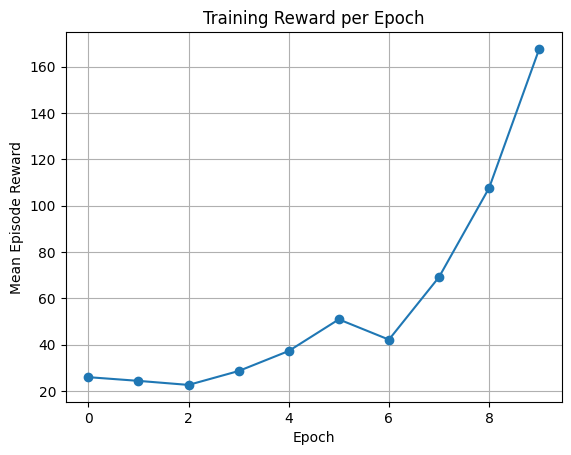

In [6]:
# Plot training rewards after training
import matplotlib.pyplot as plt
plt.plot(train_rewards, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Mean Episode Reward')
plt.title('Training Reward per Epoch')
plt.grid(True)
plt.show()

In [7]:
evaluate_policy(policy_net, n_episodes=100)

(np.float64(428.65),
 [455.0,
  313.0,
  361.0,
  500.0,
  296.0,
  267.0,
  357.0,
  364.0,
  370.0,
  500.0,
  279.0,
  370.0,
  500.0,
  500.0,
  500.0,
  500.0,
  464.0,
  500.0,
  400.0,
  484.0,
  500.0,
  500.0,
  315.0,
  394.0,
  500.0,
  500.0,
  480.0,
  270.0,
  320.0,
  500.0,
  500.0,
  500.0,
  457.0,
  500.0,
  500.0,
  426.0,
  500.0,
  323.0,
  500.0,
  500.0,
  373.0,
  500.0,
  422.0,
  499.0,
  476.0,
  408.0,
  493.0,
  359.0,
  388.0,
  389.0,
  339.0,
  500.0,
  412.0,
  500.0,
  500.0,
  395.0,
  471.0,
  500.0,
  500.0,
  381.0,
  500.0,
  289.0,
  362.0,
  360.0,
  500.0,
  324.0,
  377.0,
  290.0,
  500.0,
  289.0,
  500.0,
  414.0,
  500.0,
  500.0,
  500.0,
  292.0,
  500.0,
  483.0,
  431.0,
  500.0,
  500.0,
  418.0,
  500.0,
  259.0,
  500.0,
  500.0,
  272.0,
  500.0,
  500.0,
  348.0,
  500.0,
  275.0,
  500.0,
  374.0,
  356.0,
  444.0,
  500.0,
  318.0,
  382.0,
  438.0])

In [8]:
from tsilva_notebook_utils.gymnasium import render_episode
from tsilva_notebook_utils.gymnasium import build_env

build_env_fn = lambda **kwargs: build_env(CONFIG['env_id'], **kwargs)

render_episode(
    env=build_env_fn,
    model=policy_net
)